<a href="https://colab.research.google.com/github/LakshmiNarayana5012/AI-based-rice-yield-prediction/blob/main/Retail_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")



In [7]:
df=pd.read_csv('Superstore.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55245.233297,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
df.shape

(9994, 21)

In [10]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [11]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [13]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [14]:
df = df.dropna()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df = df.drop_duplicates()

In [17]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [18]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()

In [19]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

Total Sales: 2288271.4903
Total Profit: 284152.04339999997


In [20]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit', 'year',
       'month', 'month_name'],
      dtype='object')

In [21]:
category_sales = df.groupby("category")["sales"].sum().sort_values(ascending=False)
print(category_sales)

category
Technology         834554.2730
Furniture          736879.6953
Office Supplies    716837.5220
Name: sales, dtype: float64


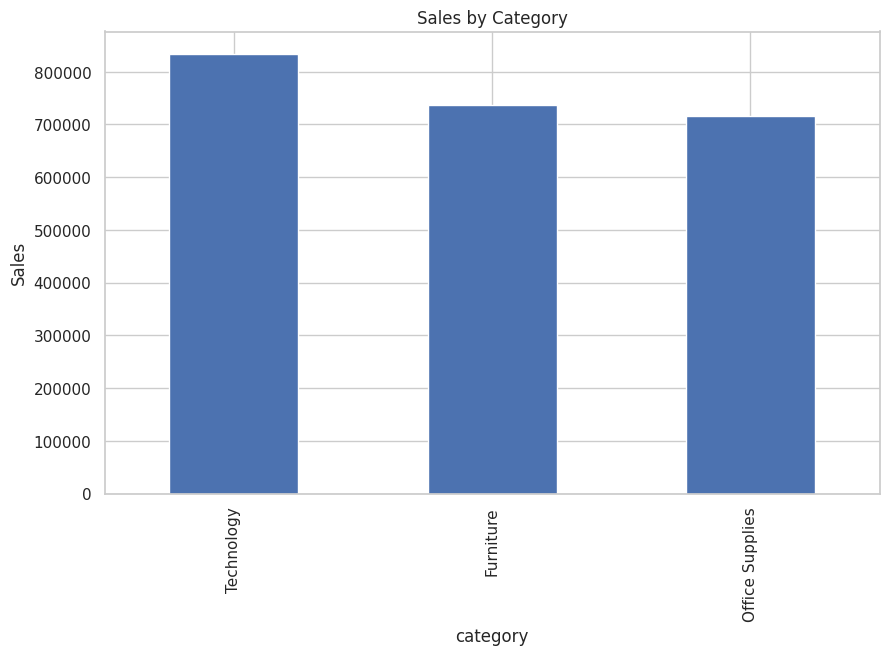

In [22]:
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

In [23]:
category_profit = df.groupby("category")["profit"].sum().sort_values(ascending=False)
print(category_profit)

category
Technology         145007.6618
Office Supplies    121885.0358
Furniture           17259.3458
Name: profit, dtype: float64


In [25]:
top_products = df.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(5)
print(top_products)

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: sales, dtype: float64


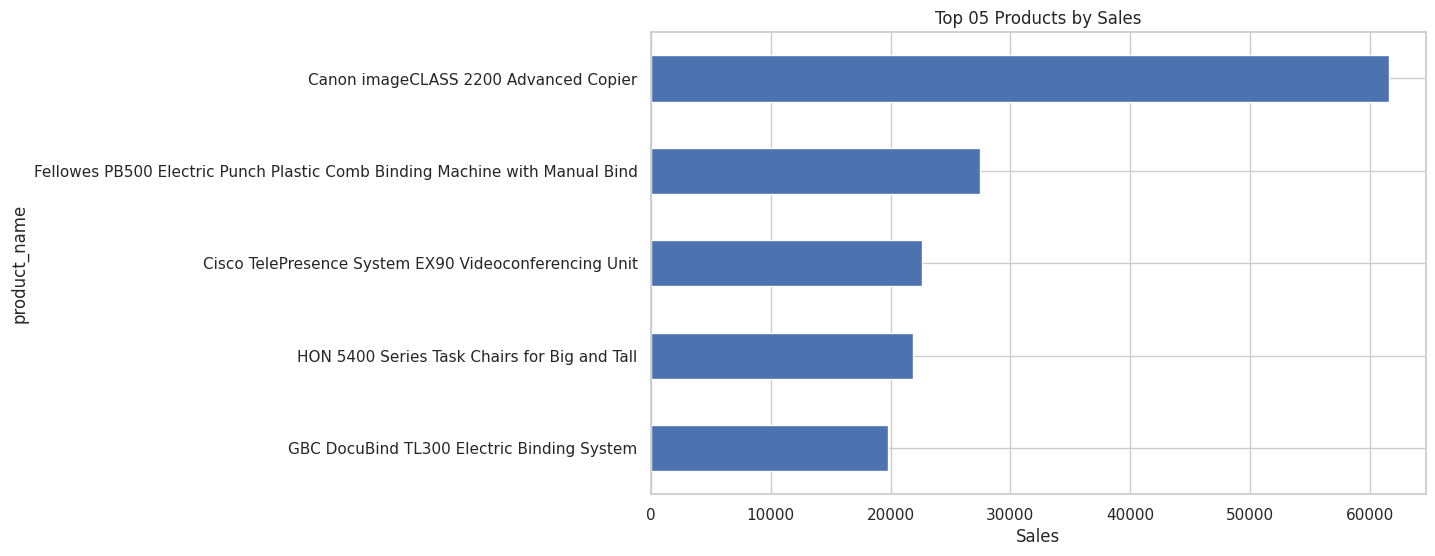

In [27]:
top_products.plot(kind="barh")
plt.title("Top 05 Products by Sales")
plt.xlabel("Sales")
plt.gca().invert_yaxis()
plt.show()

In [28]:
region_sales = df.groupby("region")["sales"].sum().sort_values(ascending=False)
print(region_sales)

region
West       725457.8245
East       669851.8700
Central    501239.8908
South      391721.9050
Name: sales, dtype: float64


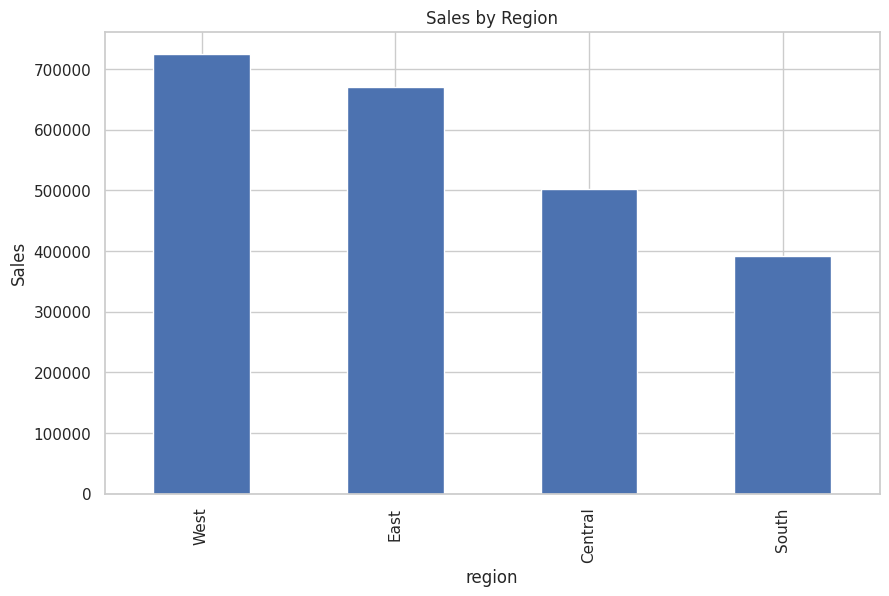

In [29]:
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

In [30]:
monthly_sales = df.groupby("month_name")["sales"].sum()
print(monthly_sales)

month_name
April        136467.3786
August       159044.0630
December     325088.4735
February      59751.2514
January       92615.3456
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     347340.9710
October      200322.9847
September    307649.9457
Name: sales, dtype: float64


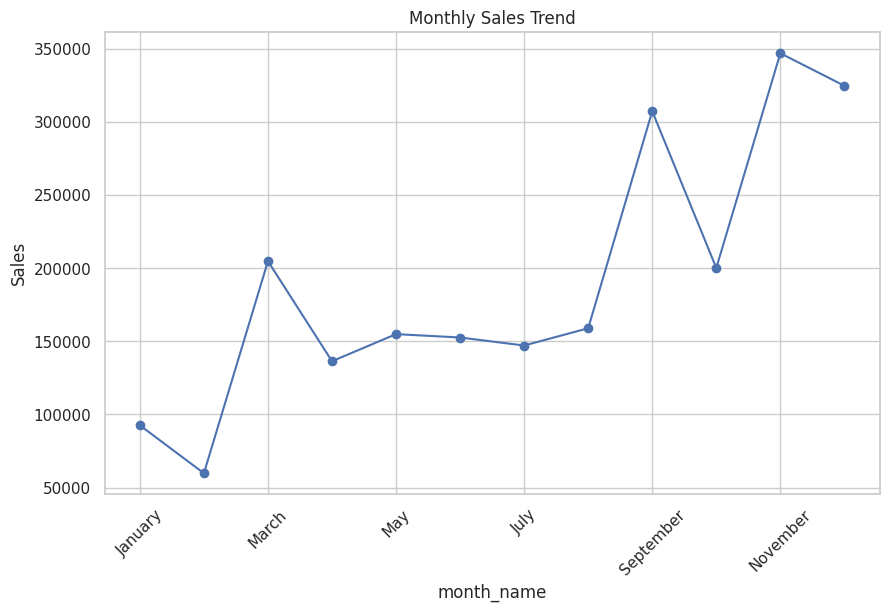

In [31]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

monthly_sales = df.groupby("month_name")["sales"].sum().reindex(month_order)

monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

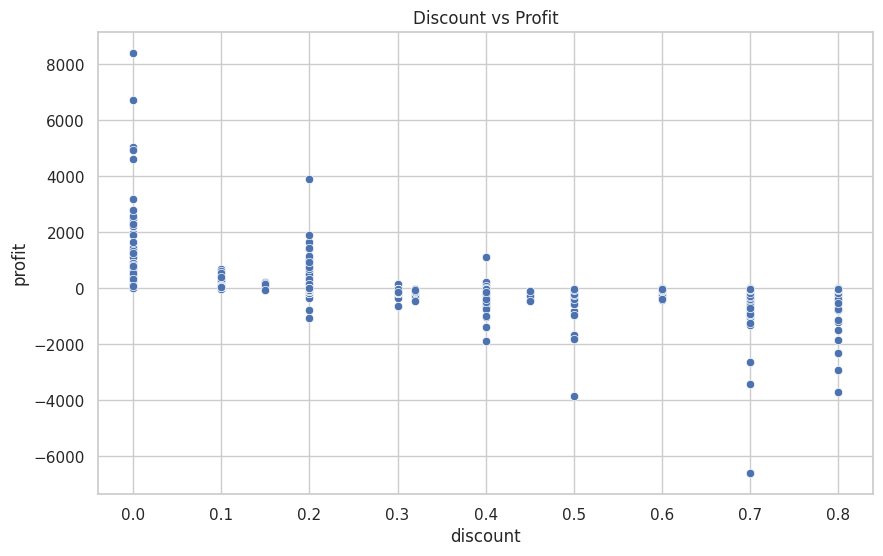

In [32]:
sns.scatterplot(data=df, x="discount", y="profit")
plt.title("Discount vs Profit")
plt.show()

In [33]:
df[["discount", "profit", "sales"]].corr()

,discount,profit,sales
discount,1.000000,-0.219182,-0.027494
profit,-0.219182,1.000000,0.477418
sales,-0.027494,0.477418,1.000000


In [34]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
best_category = df.groupby("category")["sales"].sum().idxmax()
best_region = df.groupby("region")["sales"].sum().idxmax()
top_product = df.groupby("product_name")["sales"].sum().idxmax()

print("Dashboard Summary")
print("-----------------")
print(f"Total sales: {total_sales:,.2f}")
print(f"Total profit: {total_profit:,.2f}")
print(f"Best category by sales: {best_category}")
print(f"Best region: {best_region}")
print(f"Top product: {top_product}")
print("Higher discounts often reduce profit.")

Dashboard Summary
-----------------
Total sales: 2,288,271.49
Total profit: 284,152.04
Best category by sales: Technology
Best region: West
Top product: Canon imageCLASS 2200 Advanced Copier
Higher discounts often reduce profit.


In [37]:
## Conclusion

##This project analyzed retail sales data to understand business performance across categories, products, regions, and time. The results showed that some categories and regions contribute more strongly to revenue, while discounting may reduce profitability.

##Overall, the analysis highlights that the business should balance sales growth with profit improvement. Better control of discounts, stronger inventory planning for top products, and deeper investigation into lower-performing regions can help improve future business results##